# Module 02 · Groundwork: the transform, existence and symmetry

**Book source:** Bracewell, chapter 2, pp. 5–23

Companion notebook of the lecture with the same module number. Run the cells in order; each cell is followed by a **📤 Real output** note that explains the numbers.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams.update({"figure.figsize": (7.5, 3.3), "axes.grid": True, "grid.alpha": 0.3, "figure.dpi": 110})


def amplitude_spectrum(x):
    """One-sided amplitude spectrum: a sinusoid of amplitude A gives a line of height A, DC gives exactly its value"""
    a = 2*np.abs(np.fft.rfft(x))/len(x)
    a[0] /= 2
    return a


def report(key, value, fmt=".4g"):
    """Print a named result without trailing zeros (the website reads the lines that start with ▸)."""
    s = f"{value:{fmt}}"
    if "." in s and "e" not in s:
        s = s.rstrip("0").rstrip(".")
    print(f"▸ {key} = {s}")


## 1. The transform pair and Fourier's integral theorem
🎯 **What question does this method answer?** Do the familiar transforms (Gaussian, sech, $\Pi$, $\Lambda$, a causal function) match their closed forms, do two transforms return $f(-x)$, and what does the inverse transform recover at a discontinuity? We compare numerical integration with formulas, and the DFT with a hand-built DFT matrix.

In [2]:
from scipy import integrate, special
from scipy.signal import lfilter
trap = getattr(np, "trapezoid", None) or np.trapz

def ft_support(f, a, b, s, pts=None):
    """Fourier transform (system 1) of f on [a, b] by numerical integration"""
    re = integrate.quad(lambda x: f(x)*np.cos(2*np.pi*x*s), a, b, points=pts, limit=400)[0]
    im = integrate.quad(lambda x: -f(x)*np.sin(2*np.pi*x*s), a, b, points=pts, limit=400)[0]
    return re + 1j*im

gauss = lambda x: np.exp(-np.pi*x**2)
sech = lambda x: 1/np.cosh(np.pi*x)
for s in (0.0, 0.5, 1.0):
    assert abs(ft_support(gauss, -40, 40, s) - np.exp(-np.pi*s**2)) < 1e-8
    assert abs(ft_support(sech, -40, 40, s) - 1/np.cosh(np.pi*s)) < 1e-8
report("gauss_05", ft_support(gauss, -40, 40, 0.5).real, ".4f")
report("sech_05", ft_support(sech, -40, 40, 0.5).real, ".4f")

pi05 = ft_support(lambda x: 1.0, -0.5, 0.5, 0.5); pi2 = ft_support(lambda x: 1.0, -0.5, 0.5, 2.0)
assert abs(pi05 - np.sinc(0.5)) < 1e-9 and abs(pi2) < 1e-9
report("pi_05", pi05.real, ".4f"); report("pi_2", abs(pi2), ".4f")
tri05 = ft_support(lambda x: 1 - abs(x), -1, 1, 0.5, [0])
assert abs(tri05 - np.sinc(0.5)**2) < 1e-9
report("tri_05", tri05.real, ".4f")
ea = ft_support(lambda x: np.exp(-abs(x)), -40, 40, 0.25, [0]).real
assert abs(ea - 2/(1 + 4*np.pi**2*0.25**2)) < 1e-8
report("expabs_025", ea, ".4f")
Fc1 = ft_support(lambda x: np.exp(-x), 0, 40, 0.1)               # causal function e^{-x}H(x)
assert abs(Fc1 - 1/(1 + 2j*np.pi*0.1)) < 1e-8
report("causal_mag_01", abs(Fc1), ".4f"); report("causal_ph_01", np.degrees(np.angle(Fc1)), ".2f")

# Cyclic property: F F f = f(−x). Method A: FFT; method B: hand-built DFT matrix
N = 64; nn = np.arange(N)
v = np.sin(nn**1.5) + 0.2*nn/N                                   # neither even nor odd
W = np.exp(-2j*np.pi*np.outer(nn, nn)/N)
rev = v[(-nn) % N]
ffA = np.fft.fft(np.fft.fft(v))/N; ffB = (W @ (W @ v))/N
assert np.allclose(ffA, rev) and np.allclose(ffB, rev)
f4 = np.fft.fft(np.fft.fft(np.fft.fft(np.fft.fft(v))))/N**2
assert np.allclose(f4, v)
report("cyc_err", max(np.max(np.abs(ffA - rev)), np.max(np.abs(ffB - rev))), ".1e"); report("cyc4_err", np.max(np.abs(f4 - v)), ".1e")

# Fourier's integral theorem at the jump of Π: truncate the inverse at |s| ≤ S
def inv_num(x, S):      # method A: oscillatory numerical integral
    return 2*integrate.quad(np.sinc, 0, S, weight="cos", wvar=2*np.pi*x, limit=2000)[0]
def inv_si(x, S):       # method B: closed form through the Si function
    return (special.sici(np.pi*S*(1 + 2*x))[0] + special.sici(np.pi*S*(1 - 2*x))[0])/np.pi
for S in (5, 20, 100):
    assert abs(inv_num(0.5, S) - inv_si(0.5, S)) < 1e-6
    report(f"thm_s{S}", inv_si(0.5, S), ".4f")
assert abs(inv_num(0.25, 100) - inv_si(0.25, 100)) < 1e-6 and abs(inv_num(1.0, 100) - inv_si(1.0, 100)) < 1e-6
report("thm_in", inv_si(0.25, 100), ".4f"); report("thm_out", inv_si(1.0, 100), ".4f")

▸ gauss_05 = 0.4559
▸ sech_05 = 0.3985
▸ pi_05 = 0.6366
▸ pi_2 = 0
▸ tri_05 = 0.4053
▸ expabs_025 = 0.5768
▸ causal_mag_01 = 0.8467
▸ causal_ph_01 = -32.14
▸ cyc_err = 1.8e-14
▸ cyc4_err = 5.4e-16
▸ thm_s5 = 0.4899
▸ thm_s20 = 0.4975
▸ thm_s100 = 0.4995
▸ thm_in = 0.9973
▸ thm_out = 0.0007


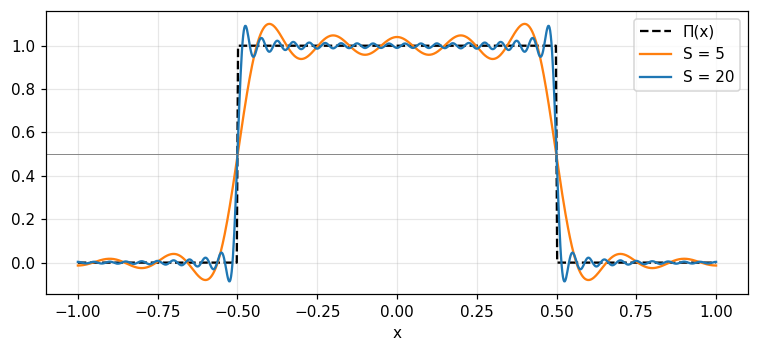

In [3]:
xx = np.linspace(-1, 1, 1001)
plt.figure(figsize=(7, 3.3))
plt.plot(xx, np.where(np.abs(xx) < 0.5 - 1e-12, 1.0, np.where(np.abs(np.abs(xx) - 0.5) <= 1e-12, 0.5, 0.0)), "k--", label="Π(x)")
for S, c in ((5, "tab:orange"), (20, "tab:blue")):
    plt.plot(xx, inv_si(xx, S), color=c, label=f"S = {S}")
plt.axhline(0.5, color="gray", lw=0.6); plt.xlabel("x"); plt.legend()
plt.tight_layout(); plt.show()

#### 📤 Real output
Numerical integration matches the closed forms: the Gaussian gives 0.4559 and sech gives 0.3985 at $s=0.5$, $\Pi$ gives 0.6366 and 0 at $s=0.5$ and $s=2$, $\Lambda$ gives 0.4053. The causal function $e^{-x}H(x)$ at $s=0.1$ has magnitude 0.8467 and phase -32.14 degrees. Two DFTs return the reversed sequence (deviation 1.8e-14) with both the FFT and the hand-built matrix, and four return the original (deviation 5.4e-16). At the jump, the inverse truncated at $S=5,20,100$ gives 0.4899, 0.4975, 0.4995, approaching 0.5; inside the pulse we get 0.9973, outside 0.0007.

## 2. Transforms in the limit
🎯 **What question does this method answer?** When a periodic function or the sign function is multiplied by a decaying factor and the factor is sent to zero, where does the sequence of transforms go? We compute the peak, width and area two ways (trapezoid rule and FFT), and compare the sign function with its closed form.

In [4]:
dx = 0.002
xg = np.arange(-150, 150, dx)
assert abs(xg[len(xg)//2]) < 1e-9
sk_all = np.fft.fftshift(np.fft.fftfreq(len(xg), dx)); ds = sk_all[1] - sk_all[0]
Fdict = {}
for tag, al in (("a1", 1.0), ("a01", 0.1), ("a001", 0.01)):
    g = np.exp(-al*xg**2)*np.cos(2*np.pi*5*xg)
    F5_trap = trap(g*np.cos(2*np.pi*5*xg), xg)                                  # method A: trapezoid rule
    F5_exact = 0.5*np.sqrt(np.pi/al)
    Fk = np.fft.fftshift(np.fft.fft(np.fft.ifftshift(g))).real*dx                 # method B: FFT of the whole record
    i5 = np.argmin(np.abs(sk_all - 5))
    assert abs(F5_trap - F5_exact)/F5_exact < 1e-6 and abs(Fk[i5] - F5_exact)/F5_exact < 1e-6
    m = (sk_all > 3) & (sk_all < 7)
    area = Fk[m].sum()*ds
    width = np.sqrt(np.sum((sk_all[m] - 5)**2*Fk[m])/np.sum(Fk[m]))
    assert abs(area - 0.5) < 5e-3 and abs(width - np.sqrt(al)/(np.pi*np.sqrt(2)))/width < 0.02
    report(f"peak_{tag}", F5_trap, ".4f"); report(f"width_{tag}", width, ".4f")
    m2 = (sk_all > 3.5) & (sk_all < 6.5); Fdict[tag] = (sk_all[m2], Fk[m2])
report("area_peak", area, ".4f")

# Sign function: sgn(x)·exp(−α|x|) at s = 0.5
def sgn_ft(al, s):
    return -2j*integrate.quad(lambda x: np.exp(-al*x), 0, np.inf, weight="sin", wvar=2*np.pi*s)[0]
closed = lambda al, s: -1j*4*np.pi*s/(al**2 + 4*np.pi**2*s**2)
for al, tag in ((0.1, "a01"), (0.01, "a001"), (0.001, "a0001")):
    assert abs(sgn_ft(al, 0.5) - closed(al, 0.5)) < 1e-9
    report(f"sgn_{tag}", sgn_ft(al, 0.5).imag, ".4f")
report("sgn_limit", (-1j/(np.pi*0.5)).imag, ".4f")

▸ peak_a1 = 0.8862
▸ width_a1 = 0.2251
▸ peak_a01 = 2.8025
▸ width_a01 = 0.0712
▸ peak_a001 = 8.8623
▸ width_a001 = 0.0225
▸ area_peak = 0.5
▸ sgn_a01 = -0.636
▸ sgn_a001 = -0.6366
▸ sgn_a0001 = -0.6366
▸ sgn_limit = -0.6366


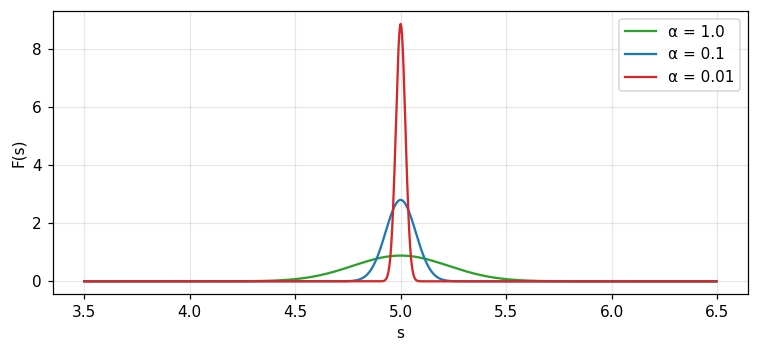

In [5]:
plt.figure(figsize=(7, 3.3))
for tag, al, c in (("a1", 1.0, "tab:green"), ("a01", 0.1, "tab:blue"), ("a001", 0.01, "tab:red")):
    plt.plot(Fdict[tag][0], Fdict[tag][1], color=c, label=f"α = {al}")
plt.xlabel("s"); plt.ylabel("F(s)"); plt.legend()
plt.tight_layout(); plt.show()

#### 📤 Real output
The peak heights 0.8862, 2.8025, 8.8623 grow like $\tfrac12\sqrt{\pi/\alpha}$, the widths shrink 0.2251, 0.0712, 0.0225, and the area stays 0.5: the sequence has no pointwise limit but defines a generalized function (an impulse pair). For the sign function the imaginary parts -0.636, -0.6366, -0.6366 approach -0.6366, exactly the $-1/(\pi s)$ of problem 3.

## 3. Even, odd and the symmetry table
🎯 **What question does this method answer?** How do we split a function into even and odd parts, which part depends on the origin, and does Bracewell's symmetry table hold for the DFT? We check with analytic formulas, numerical energy integrals, and the DFT of sequences built with each symmetry.

In [6]:
xg2 = np.linspace(-6, 6, 12001)
H = np.where(xg2 > 1e-12, 1.0, np.where(np.abs(xg2) <= 1e-12, 0.5, 0.0))
f = np.exp(-xg2)*H
ev, od = 0.5*(f + f[::-1]), 0.5*(f - f[::-1])
assert np.allclose(ev, 0.5*np.exp(-np.abs(xg2))) and np.allclose(od, 0.5*np.sign(xg2)*np.exp(-np.abs(xg2)))
i1, im1 = np.argmin(np.abs(xg2 - 1)), np.argmin(np.abs(xg2 + 1))
report("ev1", ev[i1], ".4f"); report("od1", od[i1], ".4f"); report("od_m1", od[im1], ".4f")
fe = np.exp(xg2)
assert np.allclose(0.5*(fe + fe[::-1]), np.cosh(xg2)) and np.allclose(0.5*(fe - fe[::-1]), np.sinh(xg2))
report("cosh1", np.cosh(1.0), ".4f"); report("sinh1", np.sinh(1.0), ".4f")

# Problem 17: the even plus odd energy is independent of the origin
xg3 = np.linspace(-15, 15, 300001)
for a_, tag in ((0, "a0"), (0.5, "a05"), (1, "a1"), (2, "a2")):
    g_, gm_ = np.exp(-(xg3 - a_)**2), np.exp(-(-xg3 - a_)**2)
    ee, oo = trap((0.5*(g_ + gm_))**2, xg3), trap((0.5*(g_ - gm_))**2, xg3)
    assert abs(ee + oo - np.sqrt(np.pi/2)) < 1e-6
    report(f"ev_share_{tag}", ee/(ee + oo), ".4f")
report("energy_const", np.sqrt(np.pi/2), ".4f")

# The symmetry table with the DFT (six rows)
Nq = 128; nq = np.arange(Nq); rv = (-nq) % Nq
rng = np.random.default_rng(7); a_r, b_r = rng.standard_normal(Nq), rng.standard_normal(Nq)
ev_ = lambda z: 0.5*(z + z[rv]); od_ = lambda z: 0.5*(z - z[rv])
isre = lambda z: np.max(np.abs(z.imag)) < 1e-10; isim = lambda z: np.max(np.abs(z.real)) < 1e-10
isev = lambda z: np.allclose(z, z[rv]); isod = lambda z: np.allclose(z, -z[rv])
cases = [(ev_(a_r), lambda F_: isre(F_) and isev(F_)), (od_(a_r), lambda F_: isim(F_) and isod(F_)),
         (1j*ev_(b_r), lambda F_: isim(F_) and isev(F_)), (1j*od_(b_r), lambda F_: isre(F_) and isod(F_)),
         (ev_(a_r) + 1j*od_(b_r), isre), (od_(a_r) + 1j*ev_(b_r), isim)]
Wq = np.exp(-2j*np.pi*np.outer(nq, nq)/Nq)
assert np.allclose(Wq @ cases[4][0], np.fft.fft(cases[4][0]))     # cross-check against the DFT matrix
ok = sum(bool(chk(np.fft.fft(v_))) for v_, chk in cases)
assert ok == len(cases)
report("sym_ok", ok, "d"); report("sym_total", len(cases), "d")

# A real signal: half the spectrum suffices
nr = np.arange(1000)
xr = np.cos(2*np.pi*13*nr/1000) + 0.5*np.sin(2*np.pi*77*nr/1000 + 0.4)
Xr = np.fft.fft(xr)
assert np.allclose(Xr[1:], np.conj(Xr[:0:-1]))
e_time = np.sum(xr**2)
e_half = (abs(Xr[0])**2 + 2*np.sum(abs(Xr[1:500])**2) + abs(Xr[500])**2)/1000
assert abs(e_time - e_half) < 1e-9
report("herm_full", len(Xr), "d"); report("herm_half", len(np.fft.rfft(xr)), "d"); report("herm_energy", e_time, ".4f")

▸ ev1 = 0.1839
▸ od1 = 0.1839
▸ od_m1 = -0.1839
▸ cosh1 = 1.5431
▸ sinh1 = 1.1752
▸ ev_share_a0 = 1
▸ ev_share_a05 = 0.8033
▸ ev_share_a1 = 0.5677
▸ ev_share_a2 = 0.5002
▸ energy_const = 1.2533
▸ sym_ok = 6
▸ sym_total = 6
▸ herm_full = 1000
▸ herm_half = 501
▸ herm_energy = 625


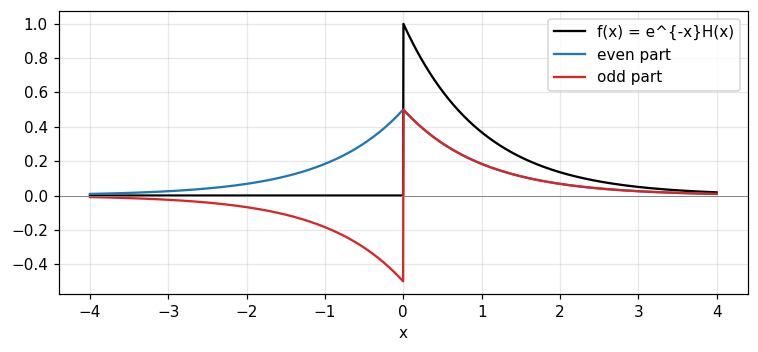

In [7]:
xp = np.linspace(-4, 4, 4001)
Hp = np.where(xp > 1e-12, 1.0, np.where(np.abs(xp) <= 1e-12, 0.5, 0.0)); fp = np.exp(-xp)*Hp
plt.figure(figsize=(7, 3.3))
plt.plot(xp, fp, "k", label="f(x) = e^{-x}H(x)")
plt.plot(xp, 0.5*(fp + fp[::-1]), "tab:blue", label=("even part"))
plt.plot(xp, 0.5*(fp - fp[::-1]), "tab:red", label=("odd part"))
plt.axhline(0, color="gray", lw=0.6); plt.xlabel("x"); plt.legend()
plt.tight_layout(); plt.show()

#### 📤 Real output
For $e^{-x}H(x)$ the even and odd parts at $x=1$ are 0.1839 and 0.1839, and at $x=-1$ the odd part flips to -0.1839. For $e^x$ we get $\cosh 1$ = 1.5431 and $\sinh 1$ = 1.1752. The even plus odd energy of $e^{-(x-a)^2}$ is always 1.2533 whatever the shift, while the even share is 1, 0.8033, 0.5677, 0.5002 for $a=0,0.5,1,2$. The DFT satisfies 6 of 6 symmetry rows. A real signal has 1000 coefficients but only 501 independent ones, and the energy 625 is fully recovered from half the spectrum.

## 4. Complex conjugates, cosine and sine transforms
🎯 **What question does this method answer?** Is the eight-line table on complex conjugates correct, and for the causal $e^{-x}H(x)$ does the Fourier transform equal $\tfrac12F_c-\tfrac12iF_s$? We check the table with the DFT and the cosine and sine transforms by numerical integration against closed forms.

In [8]:
fz = a_r + 1j*b_r
Fz = np.fft.fft(fz); cj = np.conj
rows = [(np.fft.fft(cj(fz)), cj(Fz)[rv]), (np.fft.fft(cj(fz)[rv]), cj(Fz)), (np.fft.fft(fz[rv]), Fz[rv]),
        (np.fft.fft(2*fz.real), Fz + cj(Fz)[rv]), (np.fft.fft(2j*fz.imag), Fz - cj(Fz)[rv]),
        (np.fft.fft(fz + cj(fz)[rv]), 2*Fz.real), (np.fft.fft(fz - cj(fz)[rv]), 2j*Fz.imag)]
conj_ok = sum(bool(np.allclose(l_, r_)) for l_, r_ in rows)
assert conj_ok == 7
report("conj_ok", conj_ok, "d")

s0 = 0.2                                                          # cosine and sine transforms of e^{-x}
Fc = 2*integrate.quad(lambda x: np.exp(-x), 0, np.inf, weight="cos", wvar=2*np.pi*s0)[0]
Fs = 2*integrate.quad(lambda x: np.exp(-x), 0, np.inf, weight="sin", wvar=2*np.pi*s0)[0]
Fc_ex, Fs_ex = 2/(1 + 4*np.pi**2*s0**2), 2*(2*np.pi*s0)/(1 + 4*np.pi**2*s0**2)
assert abs(Fc - Fc_ex) < 1e-9 and abs(Fs - Fs_ex) < 1e-9
F_caus = 1/(1 + 2j*np.pi*s0)
assert abs(0.5*Fc - 0.5j*Fs - F_caus) < 1e-9                       # F = ½Fc − ½iFs
F_even = ft_support(lambda x: np.exp(-abs(x)), -40, 40, s0, [0]).real
assert abs(F_even - Fc_ex) < 1e-8                                  # Fourier transform of the even extension = Fc
f1 = 2*integrate.quad(lambda s: 2/(1 + 4*np.pi**2*s**2), 0, np.inf, weight="cos", wvar=2*np.pi*1.0)[0]
assert abs(f1 - np.exp(-1)) < 1e-6                                 # self-inverse: recover f(1)
report("fc_02", Fc, ".4f"); report("fs_02", Fs, ".4f")
report("f_re_02", F_caus.real, ".4f"); report("f_im_02", F_caus.imag, ".4f")
report("f1_rec", f1, ".4f")

▸ conj_ok = 7
▸ fc_02 = 0.7755
▸ fs_02 = 0.9745
▸ f_re_02 = 0.3877
▸ f_im_02 = -0.4872
▸ f1_rec = 0.3679


#### 📤 Real output
All 7 of 7 non-trivial relations in the conjugate table hold. For $e^{-x}$ at $s=0.2$: $F_c$ = 0.7755, $F_s$ = 0.9745, so $F$ has real part 0.3877 and imaginary part -0.4872, exactly $\tfrac12F_c-\tfrac12iF_s$ and exactly $1/(1+i2\pi s)$. The Fourier transform of the even extension $e^{-|x|}$ gives 0.7755, and the inverse cosine transform recovers $f(1)$ = 0.3679, exactly $e^{-1}$: the cosine transform is its own inverse.

## 5. Three pictures of the Fourier integral
🎯 **What question does this method answer?** Why is $F(s)$ small at high frequency, what is $F(0)$, and how does the spiral on the complex plane represent $F(s)$? We compute the area under $f\cos2\pi sx$ and the cumulative integral on the complex plane, each two ways.

In [9]:
fg = lambda x: np.exp(-np.pi*x**2)
area_low = ft_support(fg, -8, 8, 0.25).real; area_high = ft_support(fg, -8, 8, 2.0).real
assert abs(area_low - np.exp(-np.pi*0.25**2)) < 1e-9 and abs(area_high - np.exp(-4*np.pi)) < 1e-9
assert abs(ft_support(fg, -8, 8, 0.0).real - 1) < 1e-9             # F(0) = ∫ f
report("area_low", area_low, ".4f"); report("area_high", area_high, ".2e")

def locus(s, X=15.0, n=200001):                                     # cumulative integral ∫_0^X e^{-x}e^{-i2πsx}dx
    x = np.linspace(0, X, n); w = np.exp(-x)*np.exp(-2j*np.pi*s*x)
    return x, np.concatenate([[0], np.cumsum((w[1:] + w[:-1])/2*np.diff(x))])
loci = {}
for s_, tag in ((0.1, "01"), (0.5, "05")):
    x_, cum = locus(s_); exact = 1/(1 + 2j*np.pi*s_)
    assert abs(cum[-1] - exact) < 1e-6
    loci[tag] = cum; report(f"spiral_abs_{tag}", abs(exact), ".4f")

▸ area_low = 0.8217
▸ area_high = 3.49e-06
▸ spiral_abs_01 = 0.8467
▸ spiral_abs_05 = 0.3033


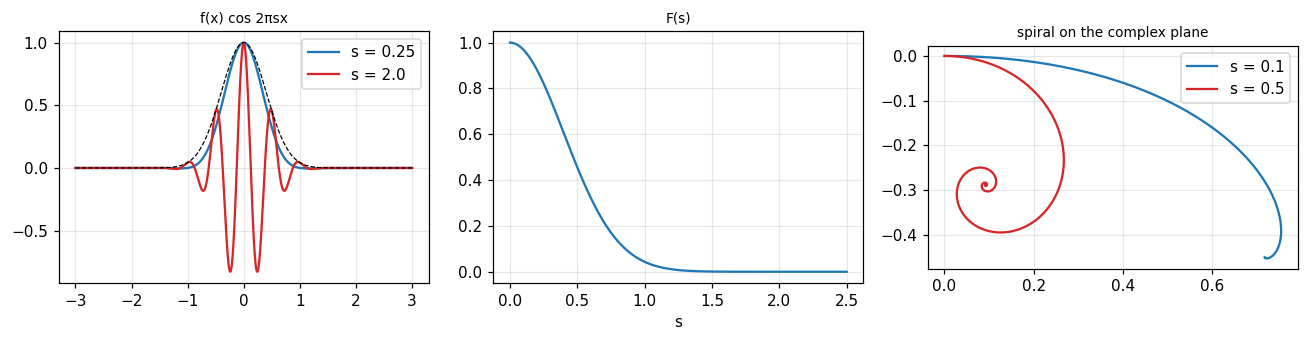

In [10]:
xs_ = np.linspace(-3, 3, 1201)
fig, ax = plt.subplots(1, 3, figsize=(12, 3.2))
for s_, c in ((0.25, "tab:blue"), (2.0, "tab:red")):
    ax[0].plot(xs_, fg(xs_)*np.cos(2*np.pi*s_*xs_), color=c, label=f"s = {s_}")
ax[0].plot(xs_, fg(xs_), "k--", lw=0.8); ax[0].legend(); ax[0].set_title("f(x) cos 2πsx", fontsize=9)
ss = np.linspace(0, 2.5, 400); ax[1].plot(ss, np.exp(-np.pi*ss**2)); ax[1].set_title("F(s)", fontsize=9); ax[1].set_xlabel("s")
for tag, c in (("01", "tab:blue"), ("05", "tab:red")):
    ax[2].plot(loci[tag].real, loci[tag].imag, color=c, label=f"s = {int(tag)/10}")
ax[2].set_aspect("equal"); ax[2].legend(); ax[2].set_title("spiral on the complex plane", fontsize=9)
plt.tight_layout(); plt.show()

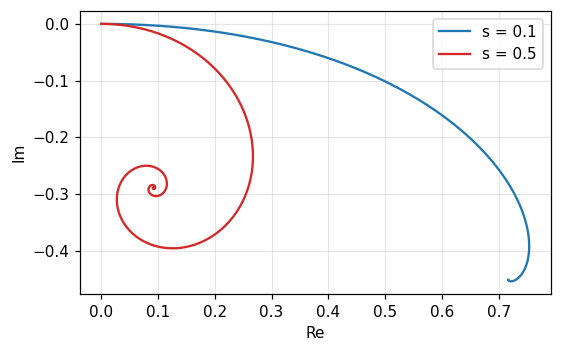

In [11]:
xs2 = np.linspace(-3, 3, 1201)
plt.figure(figsize=(5.5, 3.3))
for s_, c in ((0.1, "tab:blue"), (0.5, "tab:red")):
    x_, cum = locus(s_, 12, 4001)
    plt.plot(cum.real, cum.imag, color=c, label=f"s = {s_}")
plt.gca().set_aspect("equal"); plt.legend(); plt.xlabel("Re"); plt.ylabel("Im")
plt.tight_layout(); plt.show()

#### 📤 Real output
For the Gaussian, the area under $f\cos2\pi sx$ is 0.8217 at $s=0.25$ but only 3.49e-06 at $s=2$: fast oscillation makes the positive and negative half-cycles cancel, so $F(s)\to0$ as $s\to\infty$, and $F(0)=\int f$. The spiral of $e^{-x}H(x)$ ends at a vector of length 0.8467 for $s=0.1$ and 0.3033 for $s=0.5$; the cumulative integral matches the closed form $1/(1+i2\pi s)$.